# 1.3 Employee-well-being

## Import the Libraries

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## Import the Dataset

In [158]:
df = pd.read_csv("wellbeing_of_employees.csv")

## Analyzing the Dataset

In [159]:
df.shape

(15972, 16)

In [160]:
df.head()

,EMPLOYEE_ID,JOB_ROLE,TEAM_SIZE,MONTHLY_EXTRA_HOURS,EXTRA_HOLIDAYS,TODO_COMPLETED,BMI_RANGE,DAILY_STEPS_IN_THOUSAND,SLEEP_HOURS,DAILY_STRESS,TIME_FOR_HOBBY,HEALTHY_MEALS_PER_WEEK,SUFFICIENT_INCOME,AGE,GENDER,WORK_LIFE_BALANCE_SCORE
0,1,City Bus Driver,10,6,1,0,1,1,8,5.0,0,1,1,21 to 35,Female,557.9
1,2,City Bus Driver,0,8,5,8,2,4,8,3.0,5,8,2,51 or more,Female,737.0
2,3,Fleet Manager,0,10,5,5,1,10,7,2.0,6,10,2,21 to 35,Female,761.8
3,4,Logistics Coordinator,5,10,5,8,1,10,6,2.0,8,10,2,51 or more,Female,736.1
4,5,Logistics Coordinator,5,1,1,4,1,3,8,1.0,1,7,2,36 to 50,Male,655.2


In [161]:
df.columns

Index(['EMPLOYEE_ID', 'JOB_ROLE', 'TEAM_SIZE', 'MONTHLY_EXTRA_HOURS',
       'EXTRA_HOLIDAYS', 'TODO_COMPLETED', 'BMI_RANGE',
       'DAILY_STEPS_IN_THOUSAND', 'SLEEP_HOURS', 'DAILY_STRESS',
       'TIME_FOR_HOBBY', 'HEALTHY_MEALS_PER_WEEK', 'SUFFICIENT_INCOME', 'AGE',
       'GENDER', 'WORK_LIFE_BALANCE_SCORE'],
      dtype='object')

### Check unique values in categorical columns

In [162]:
print("Unique JOB_ROLES:", df['JOB_ROLE'].unique())
print("\nGenders:", df['GENDER'].unique())
print("\nTEAM_SIZE:", df['TEAM_SIZE'].unique())
print("\nMONTHLY_EXTRA_HOURS:", df['MONTHLY_EXTRA_HOURS'].unique())
print("\nEXTRA_HOLIDAYS:", df['EXTRA_HOLIDAYS'].unique())
print("\nTODO_COMPLETED:", df['TODO_COMPLETED'].unique())
print("\nBMI_RANGE:", df['BMI_RANGE'].unique())
print("\nDAILY_STEPS_IN_THOUSAND:", df['DAILY_STEPS_IN_THOUSAND'].unique())
print("\nSLEEP_HOURS:", df['SLEEP_HOURS'].unique())
print("\nDAILY_STRESS:", df['DAILY_STRESS'].unique())
print("\nTIME_FOR_HOBBY:", df['TIME_FOR_HOBBY'].unique())
print("\nHEALTHY_MEALS_PER_WEEK:", df['HEALTHY_MEALS_PER_WEEK'].unique())
print("\nSUFFICIENT_INCOME:", df['SUFFICIENT_INCOME'].unique())
print("\nAGE:", df['AGE'].unique())

Unique JOB_ROLES: ['City Bus Driver' 'Fleet Manager' 'Logistics Coordinator' 'Depot Driver'
 'Train Conductor' 'Environmental and Sustainability Manager'
 'Maintenance Technician' 'Operations Manager' 'Intercity Bus Driver']

Genders: ['Female' 'Male']

TEAM_SIZE: [10  0  5  6  3  9  8  1  4  2  7]

MONTHLY_EXTRA_HOURS: [ 6  8 10  1  4  5  3  7  2  0  9]

EXTRA_HOLIDAYS: [1 5 0 3 2 4]

TODO_COMPLETED: ['0' '8' '5' '4' '7' '14:30' '9' '3' '6' '2' '1' '10']

BMI_RANGE: [1 2]

DAILY_STEPS_IN_THOUSAND: [ 1  4 10  3  6  2  5  8  7  9]

SLEEP_HOURS: [ 8  7  6  9 10  4  5  2  3  1]

DAILY_STRESS: [ 5.  3.  2.  1.  4.  0. nan]

TIME_FOR_HOBBY: [ 0  5  6  8  1  2  3  4 10  7  9]

HEALTHY_MEALS_PER_WEEK: [ 1  8 10  7  4  9  3  5  0  2  6]

SUFFICIENT_INCOME: [1 2]

AGE: ['21 to 35' '51 or more' '36 to 50' 'Less than 20']


### Checking for more null values in the dataset

In [163]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 EMPLOYEE_ID                0
JOB_ROLE                   0
TEAM_SIZE                  0
MONTHLY_EXTRA_HOURS        0
EXTRA_HOLIDAYS             0
TODO_COMPLETED             0
BMI_RANGE                  0
DAILY_STEPS_IN_THOUSAND    0
SLEEP_HOURS                0
DAILY_STRESS               1
TIME_FOR_HOBBY             0
HEALTHY_MEALS_PER_WEEK     0
SUFFICIENT_INCOME          0
AGE                        0
GENDER                     0
WORK_LIFE_BALANCE_SCORE    0
dtype: int64


### Data Analysis Summary

Based on the provided feature overview, here are the key preprocessing requirements:

1. **Categorical Encoding**
   The following categorical features need to be encoded (e.g., using Label Encoding or One-Hot Encoding):

   * `JOB_ROLES`: 9 unique roles (e.g., City Bus Driver, Fleet Manager, etc.)
   * `Genders`: \['Female', 'Male']
   * `AGE`: \['Less than 20', '21 to 35', '36 to 50', '51 or more']

2. **Cleaning and Type Conversion**

   * `TODO_COMPLETED` contains mostly numeric string values, but also includes an invalid entry `'14:30'`, which appears to be an error and should be either corrected or removed.
   * All valid entries in this column should be converted from strings to integers.

3. **Handling Missing Values**

   * `DAILY_STRESS` contains missing (`NaN`) values. Rows with missing values should be dropped.

4. **Missing Values Summary**
    * Out of all the features, only one column contains missing data:
      * DAILY_STRESS has 1 missing value.
    * To ensure data consistency and avoid issues during modeling, this row should be dropped during preprocessing.
    * All other columns are complete and contain no missing value 



## Data Cleaning and Preprocessing

In [164]:
# Drop irrelevant columns
# Justification: EMPLOYEE_ID is just an identifier, not useful for prediction.
df.drop(columns=['EMPLOYEE_ID'], inplace=True)

# Fixing non-numeric values
df['TODO_COMPLETED'] = pd.to_numeric(df['TODO_COMPLETED'], errors='coerce')

# Drop rows with NaN values
df.dropna(inplace=True)

# Convert categorical variables to numeric
le_job = LabelEncoder()
df['JOB_ROLE'] = le_job.fit_transform(df['JOB_ROLE'])

le_age = LabelEncoder()
df['AGE'] = le_age.fit_transform(df['AGE'])

le_gender = LabelEncoder()
df['GENDER'] = le_gender.fit_transform(df['GENDER'])  # Male = 1, Female = 0

# Clean data
print("Cleaned Data Sample:\n", df.head())

Cleaned Data Sample:
    JOB_ROLE  TEAM_SIZE  MONTHLY_EXTRA_HOURS  EXTRA_HOLIDAYS  TODO_COMPLETED  \
0         0         10                    6               1             0.0   
1         0          0                    8               5             8.0   
2         3          0                   10               5             5.0   
3         5          5                   10               5             8.0   
4         5          5                    1               1             4.0   

   BMI_RANGE  DAILY_STEPS_IN_THOUSAND  SLEEP_HOURS  DAILY_STRESS  \
0          1                        1            8           5.0   
1          2                        4            8           3.0   
2          1                       10            7           2.0   
3          1                       10            6           2.0   
4          1                        3            8           1.0   

   TIME_FOR_HOBBY  HEALTHY_MEALS_PER_WEEK  SUFFICIENT_INCOME  AGE  GENDER  \
0               0

## Graphical Representations to get some Insights

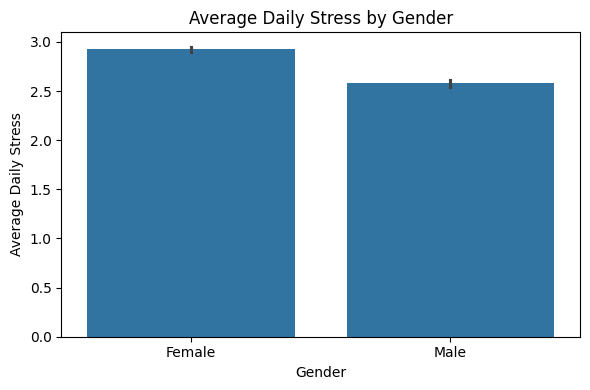

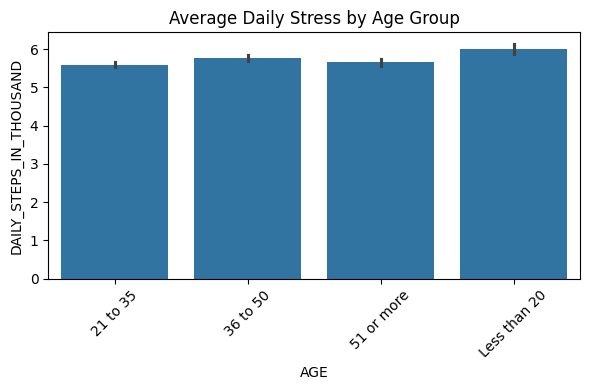

In [165]:
# Average daily stress by gender
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='GENDER', y='DAILY_STRESS')
plt.title("Average Daily Stress by Gender")
plt.xticks(ticks=[0,1], labels=['Female', 'Male'])
plt.ylabel("Average Daily Stress")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

# Average daily stress by age
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='AGE', y='DAILY_STEPS_IN_THOUSAND')
plt.title("Average Daily Stress by Age Group")
plt.xticks(ticks=range(len(le_age.classes_)), labels=le_age.classes_, rotation=45)
plt.tight_layout()
plt.show()

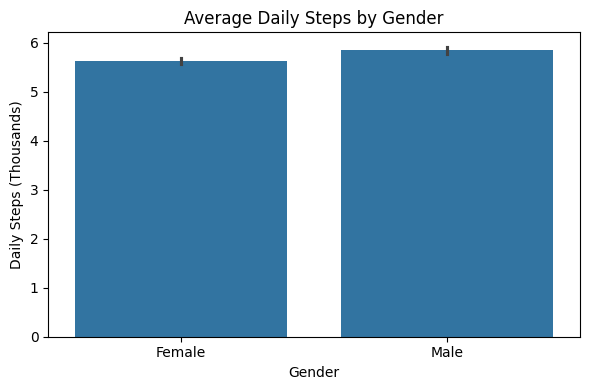

In [166]:
# Daily steps by gender
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='GENDER', y='DAILY_STEPS_IN_THOUSAND')
plt.title("Average Daily Steps by Gender")
plt.xticks(ticks=[0,1], labels=['Female', 'Male'])
plt.ylabel("Daily Steps (Thousands)")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

Based on the bar plot, we can conclude that males, on average, take more daily steps compared to females.

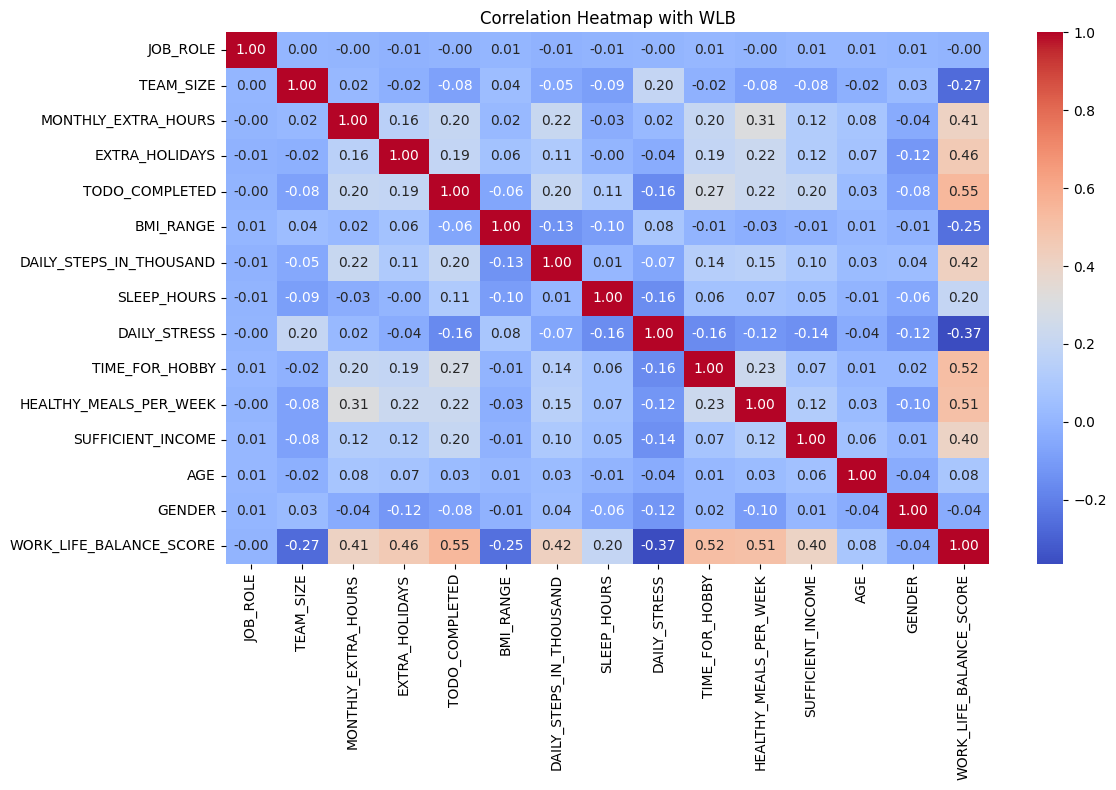

In [167]:
# Heatmap to see correlations with WLB
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap with WLB")
plt.tight_layout()
plt.show()

In [168]:
# Compute correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Get correlation of all features with WORK_LIFE_BALANCE_SCORE
wlb_correlation = correlation_matrix["WORK_LIFE_BALANCE_SCORE"].drop("WORK_LIFE_BALANCE_SCORE").sort_values(ascending=False)

# Round to 2 decimals
wlb_correlation_rounded = wlb_corr.round(2)

# Display the sorted correlations
print(wlb_correlation_rounded)

TODO_COMPLETED             0.55
TIME_FOR_HOBBY             0.52
HEALTHY_MEALS_PER_WEEK     0.51
EXTRA_HOLIDAYS             0.46
DAILY_STEPS_IN_THOUSAND    0.42
MONTHLY_EXTRA_HOURS        0.41
SUFFICIENT_INCOME          0.40
SLEEP_HOURS                0.20
AGE                        0.08
JOB_ROLE                  -0.00
GENDER                    -0.04
BMI_RANGE                 -0.25
TEAM_SIZE                 -0.27
DAILY_STRESS              -0.37
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64


### Summary of Correlation Analysis with Work Life Balance Score (WLB)

The strongest positive factors linked to better work-life balance are:

- **To-Dos Completed (0.55)**
- **Time for Hobby (0.52)**
- **Healthy Meals per Week (0.51)**
- **Extra Holidays (0.46)**
- **Daily Steps (0.42)**
- **Sufficient Income (0.40)**

**Sleep hours** comparetively show a weak positive correlation, while **job role**, **age** and **gender** have little to no effect.

Negative correlations include:

- **Daily Stress (-0.37)**
- **Team Size (-0.27)**
- **BMI Range (-0.25)**

---

### Key Insights

Employees with healthier lifestyles, more leisure time, and adequate income report better work-life balance. High stress, larger teams, and higher BMI negatively impact balance. Managing stress, encouraging healthy habits, and providing sufficient breaks and holidays could improve overall well-being.


# 1.4 Predictive Well Being Algorithm

In [169]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

In [170]:
# Define features and label
## Independant Variables 
X = df.drop(columns=['WORK_LIFE_BALANCE_SCORE'])
## Dependant Variable 
y = df['WORK_LIFE_BALANCE_SCORE']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}\n")

R² Score: 0.8609



In [171]:
# First 20 values comparison
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}).head(20)

# Round predicted values
comparison_df['Predicted'] = comparison_df['Predicted'].round(2)

print("+-------+-----------+-------------+")
print("| Index |  Actual   |  Predicted  |")
print("+-------+-----------+-------------+")
for i, row in comparison_df.iterrows():
    print(f"| {i:^5} | {row['Actual']:^9.1f} | {row['Predicted']:^11.2f} |")
print("+-------+-----------+-------------+")

+-------+-----------+-------------+
| Index |  Actual   |  Predicted  |
+-------+-----------+-------------+
|   0   |   688.8   |   676.18    |
|   1   |   703.4   |   690.46    |
|   2   |   673.2   |   676.80    |
|   3   |   662.0   |   682.51    |
|   4   |   693.7   |   658.98    |
|   5   |   595.5   |   591.03    |
|   6   |   649.5   |   659.69    |
|   7   |   644.4   |   632.20    |
|   8   |   688.5   |   703.32    |
|   9   |   660.5   |   621.24    |
|  10   |   637.3   |   658.91    |
|  11   |   682.4   |   667.97    |
|  12   |   620.8   |   606.17    |
|  13   |   638.6   |   671.78    |
|  14   |   676.2   |   668.41    |
|  15   |   674.1   |   668.06    |
|  16   |   698.1   |   699.95    |
|  17   |   684.1   |   685.84    |
|  18   |   702.1   |   728.68    |
|  19   |   674.7   |   718.56    |
+-------+-----------+-------------+


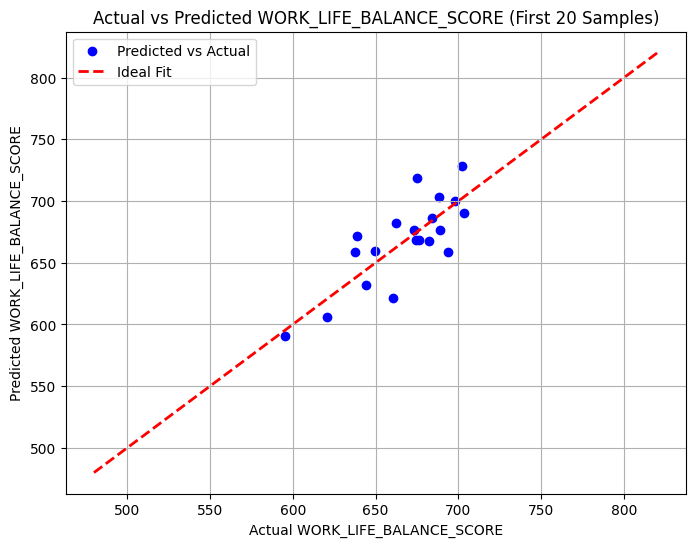

In [172]:
plt.figure(figsize=(8,6))
plt.scatter(y_test[:20], y_pred[:20], color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual WORK_LIFE_BALANCE_SCORE')
plt.ylabel('Predicted WORK_LIFE_BALANCE_SCORE')
plt.title('Actual vs Predicted WORK_LIFE_BALANCE_SCORE (First 20 Samples)')
plt.legend()
plt.grid(True)
plt.show()

## Predict WLB for a new employee record

In [173]:
new_employee = pd.DataFrame([{
    'JOB_ROLE': le_job.transform(['Train Conductor'])[0],
    'TEAM_SIZE': 3,
    'MONTHLY_EXTRA_HOURS': 5,
    'EXTRA_HOLIDAYS': 1,
    'TODO_COMPLETED': 7,
    'BMI_RANGE': 2,
    'DAILY_STEPS_IN_THOUSAND': 7,
    'SLEEP_HOURS': 6,
    'DAILY_STRESS': 3,
    'TIME_FOR_HOBBY': 4,
    'HEALTHY_MEALS_PER_WEEK': 6,
    'SUFFICIENT_INCOME': 2,
    'AGE': le_age.transform(['21 to 35'])[0],
    'GENDER': le_gender.transform(['Male'])[0],
}])

new_employee_wlb_prediction = lr.predict(new_employee)
print(f"Predicted WLB score for new employee: {new_employee_wlb_prediction[0]:.2f}")

Predicted WLB score for new employee: 655.26


## Represent the summary of the model

In [174]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     WORK_LIFE_BALANCE_SCORE   R-squared:                       0.859
Model:                                 OLS   Adj. R-squared:                  0.859
Method:                      Least Squares   F-statistic:                     6970.
Date:                     Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                             23:28:53   Log-Likelihood:                -67791.
No. Observations:                    15970   AIC:                         1.356e+05
Df Residuals:                        15955   BIC:                         1.357e+05
Df Model:                               14                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

### Findings

- The p-value for **JOB_ROLE** is 0.946, which is very high (much greater than the common significance level of 0.05).
- This indicates that **JOB_ROLE** is not statistically significant in predicting the Work Life Balance score in this model.
- In other words, variations in **JOB_ROLE** do not have a meaningful linear relationship with the WLB score after accounting for other variables.
- Including such a variable may add noise or reduce model simplicity without improving prediction.



In [175]:
X2 = X.drop(['JOB_ROLE'], axis=1)
X2_const = sm.add_constant(X2)
model = sm.OLS(y, X2_const).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     WORK_LIFE_BALANCE_SCORE   R-squared:                       0.859
Model:                                 OLS   Adj. R-squared:                  0.859
Method:                      Least Squares   F-statistic:                     7507.
Date:                     Mon, 14 Jul 2025   Prob (F-statistic):               0.00
Time:                             23:28:54   Log-Likelihood:                -67791.
No. Observations:                    15970   AIC:                         1.356e+05
Df Residuals:                        15956   BIC:                         1.357e+05
Df Model:                               13                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

### Work-Life Balance Analysis at FAU Transline

#### Compensation  
**Sufficient income** is the most impactful factor for improving work-life balance.

#### Well-being & Lifestyle  
**Time for hobbies**, **healthy meals per week**, **adequate sleep**, and **daily physical activity** all contribute positively to WLB. These lifestyle habits are closely linked to mental and physical well-being, making them crucial levers for improving overall employee satisfaction.

#### Work Conditions  
**Extra holidays** are strongly associated with better WLB, indicating the value of time off.  
**Task completion (To-Do Completed)** suggests that employees who manage their workload efficiently feel more balanced.  
Interestingly, **monthly extra hours** also show a positive impact—possibly indicating that when extra work is manageable and appreciated, it doesn't harm WLB.

#### Low-Impact Demographics  
**Age** and **gender** have statistically significant but minimal impact on WLB. Males show a slightly higher WLB score, but this difference is not large enough to warrant targeted changes.

#### Health & Stress  
**High daily stress levels** and **unhealthy BMI** negatively affect WLB. Stress is a clear burden, and poor health may amplify it. Addressing these areas is critical for sustainable well-being.

#### Team Structure  
**Larger team sizes** are linked to lower WLB. This could be due to communication overhead or diluted responsibility. More focused, smaller teams may improve individual experience.

---

#### Recommendations for FAU Transline

- **Improve compensation** through competitive salaries or benefits.
- **Promote healthy living** via wellness programs, fitness challenges, and nutrition awareness.
- **Encourage hobbies and rest** by supporting personal time and flexible scheduling.
- **Reduce stress** with mental health support, realistic deadlines, and employee check-ins.
- **Offer more leave** or flexible holiday options to recharge employees.
- **Keep teams lean** to foster ownership and better communication.
- **Maintain equity** by ensuring fair treatment across age and gender, even if current effects are minimal.
